In [1]:
import os
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Questions to answer:\
1.1 - How does layerwise rep dim change when whole model is pruned? \
1.2 - How does layerwise rep dim change when only that layer is pruned? \
1.3 - Is layerwise rep dim change predictive of model performance changes? 

### Helper Functions

In [ ]:
read_results(prune_method='random', metric='knn_acc', prune_all=False)

(2, 10)

In [23]:
def read_results(prune_method='random', metric="eff_dim", prune_all=True, model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']
    assert metric in ['eff_dim', 'pca_dim', 'val_acc', 'knn_acc']
    assert model_name in ['vgg']

    results_file = f'./results/{model_name}_{metric}_{prune_method}_{"all" if prune_all else "layerwise"}.csv'

    df = pd.read_csv(results_file)


    # if there is a layer_name == Input, drop it and store the layer names in a list
    if 'layer_name' in df.columns:
        df = df[df['layer_name'] != 'Input']

    
    if metric == 'eff_dim' or metric == 'pca_dim' or metric == 'knn_acc': # return np array of [n_layers x n_sparsity_levels]
        res = df.iloc[:, 1:].to_numpy()
    
    elif metric == 'val_acc' and prune_all: # return np array of [n_sparsity_levels,2] 2 for top1 and top5
        res = df.to_numpy().T.astype(float)
    
    elif metric == 'val_acc' and not prune_all: # return np array of [n_layers, n_sparsity_levels, 2] 2 for top1 and top5
        res = df.iloc[:, 1:].to_numpy()
        res = np.array([[ast.literal_eval(x) for x in row] for row in res]).astype(float) # convert string representation of list to list of floats
    
    
    return res

def get_layer_names(prune_method='random', metric="eff_dim", prune_all=True, model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']
    assert metric in ['eff_dim', 'pca_dim', 'val_acc', 'knn_acc']
    assert model_name in ['vgg']

    results_file = f'./results/{model_name}_{metric}_{prune_method}_{"all" if prune_all else "layerwise"}.csv'

    df = pd.read_csv(results_file)

    if 'layer_name' in df.columns:
        layer_names = df['layer_name'].to_list()
        layer_names = [name for name in layer_names if name != 'Input']
        return layer_names
    else:
        return None
    
def get_sparsity_levels(prune_method='random', metric="eff_dim", prune_all=True, model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']
    assert metric in ['eff_dim', 'pca_dim', 'val_acc', 'knn_acc']
    assert model_name in ['vgg']

    results_file = f'./results/{model_name}_{metric}_{prune_method}_{"all" if prune_all else "layerwise"}.csv'

    df = pd.read_csv(results_file)

    sparsity_levels = df.columns[1:].to_list() # first column is layer name
    sparsity_levels = [float(s.split('sparsity_')[1]) for s in sparsity_levels]
    return sparsity_levels


In [5]:
layer_names = get_layer_names(prune_method='random', metric='eff_dim', prune_all=False)
sparsity_levels = get_sparsity_levels(prune_method='random', metric='eff_dim', prune_all=False)

print(layer_names)
print(sparsity_levels)
methods = ['random', 'amp', 'svd']
colors =  ['blue', 'orange', 'green']

['Conv1', 'Conv2', 'Conv3', 'Conv4', 'Conv5', 'Conv6', 'Conv7', 'Conv8', 'Conv9', 'Conv10', 'Conv11', 'Conv12', 'Conv13', 'Linear1', 'Linear2']
[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


### Q0. How does weight sparsity affect performance?

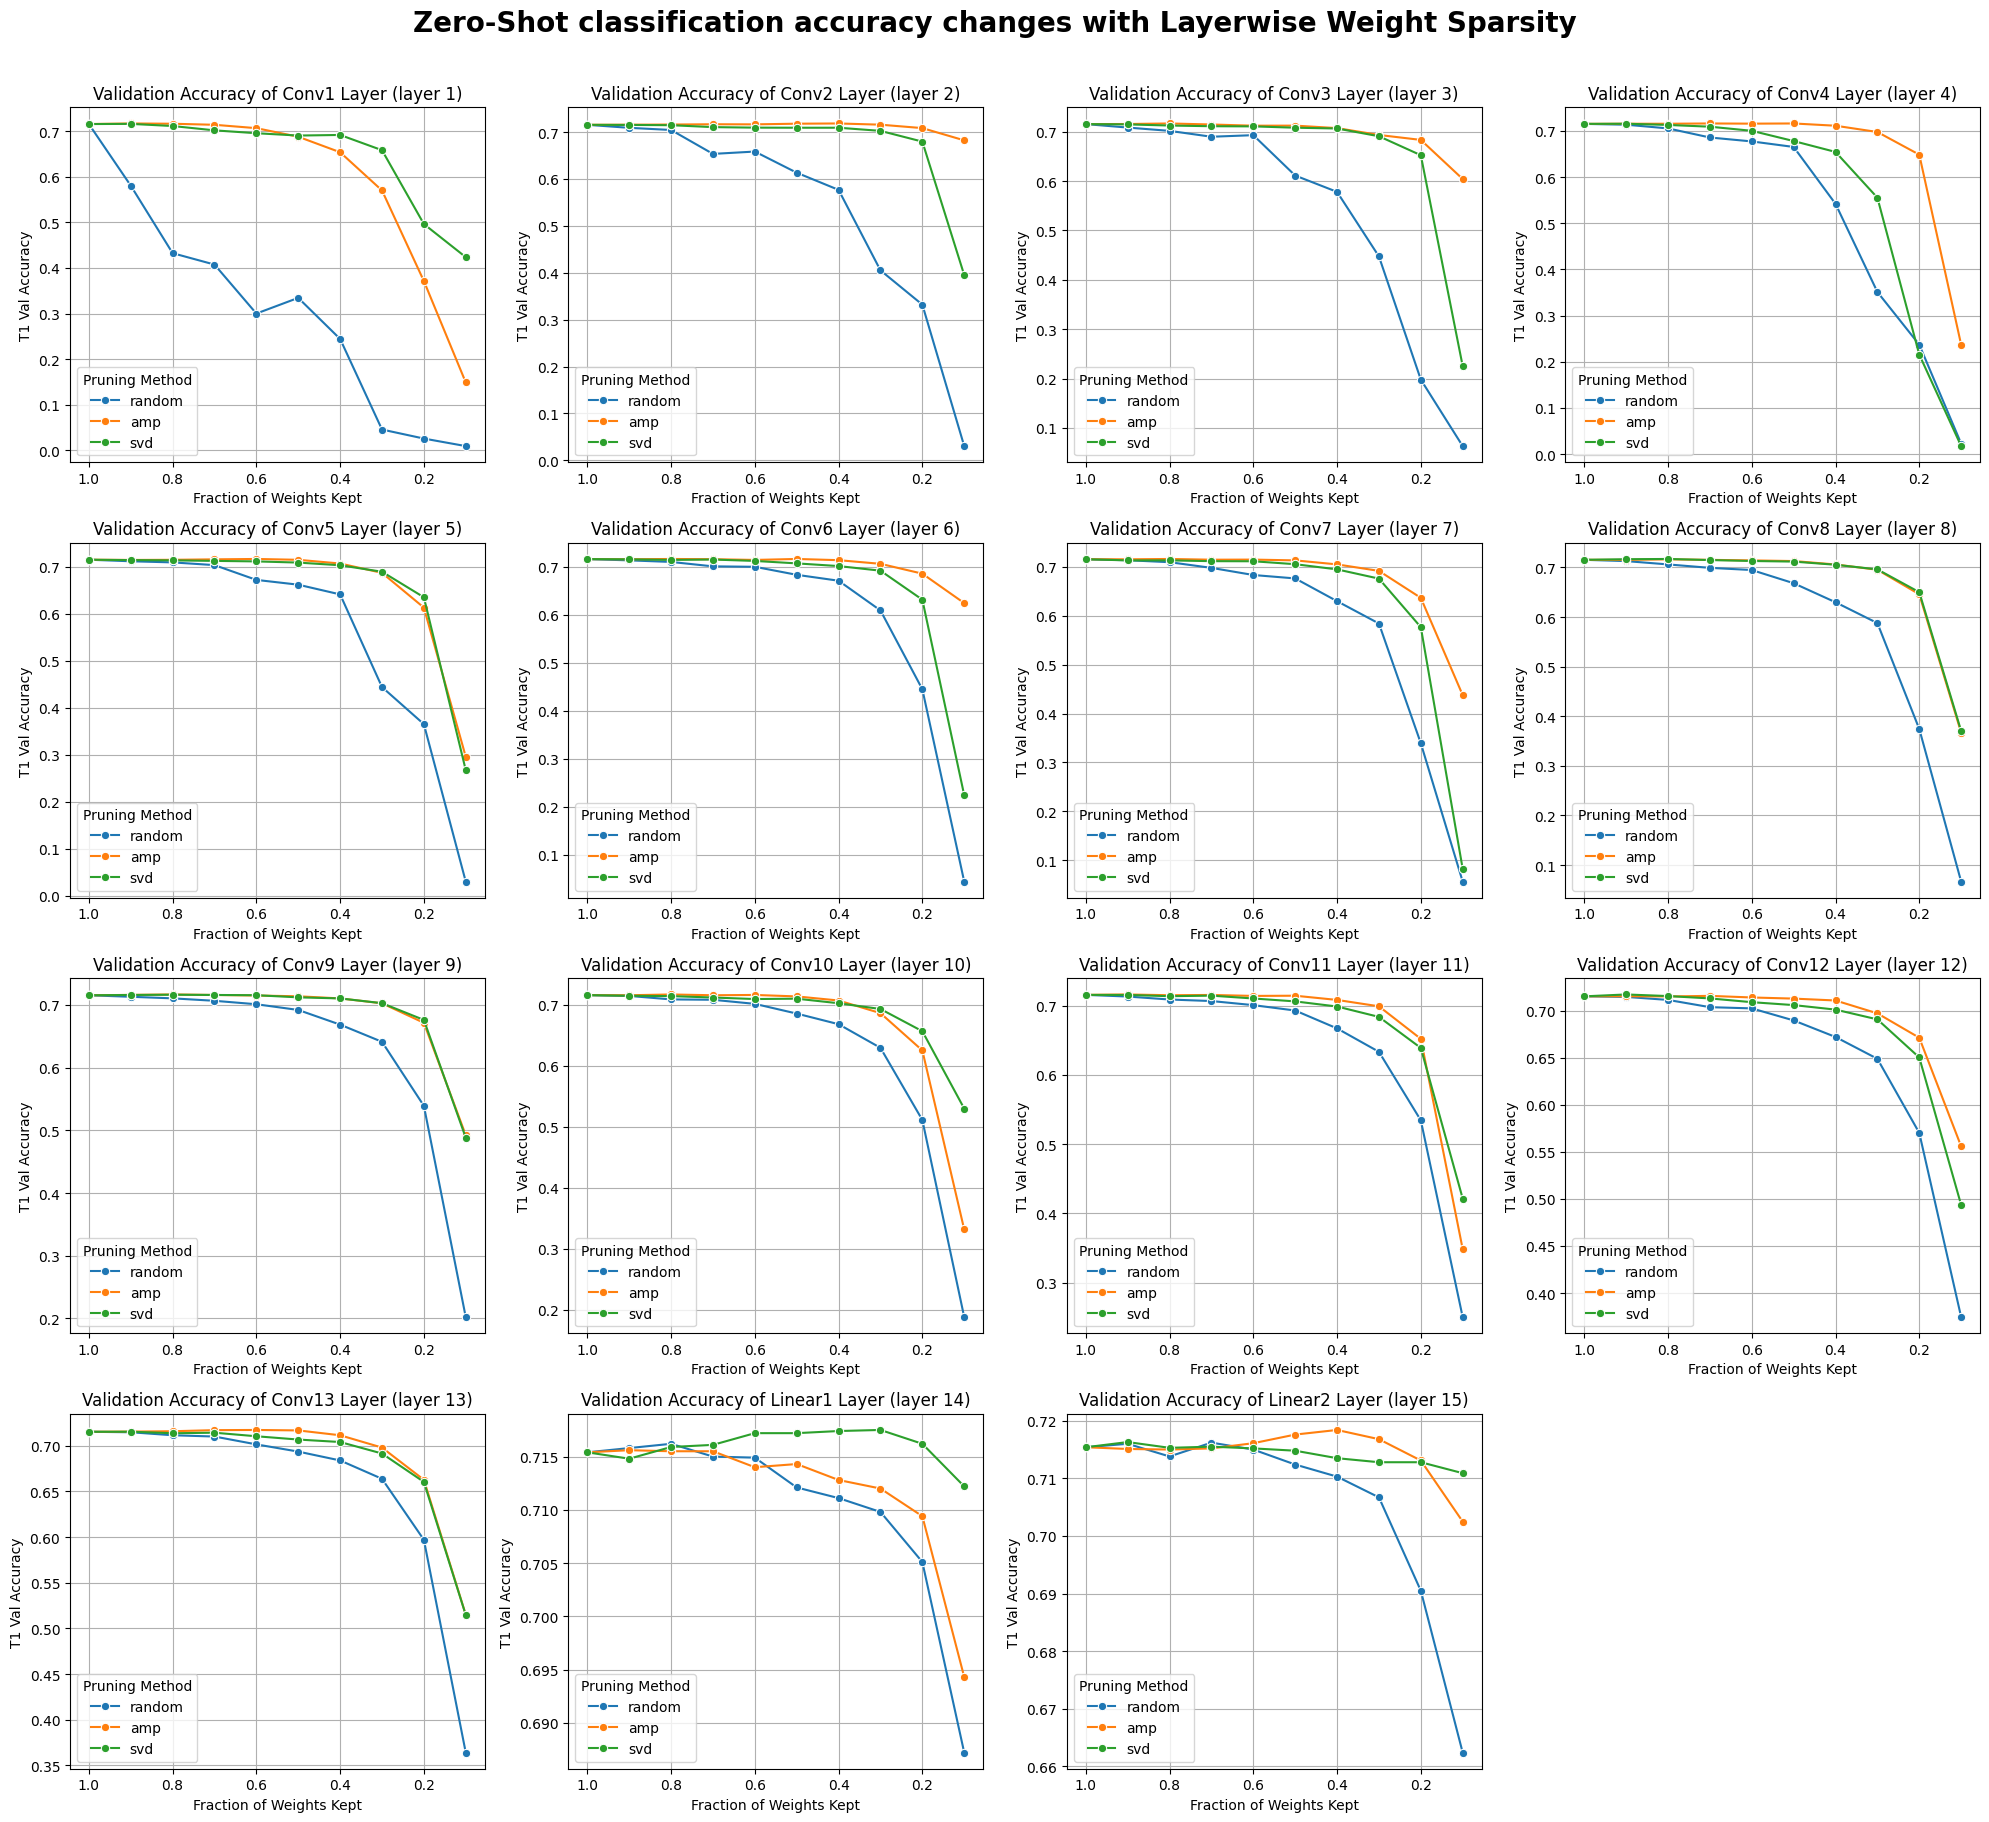

In [3]:
# subplots for each layer showing how the pca dim changes with sparsity level for each method (all 3 methods)
val_accs_random_layerwise = read_results(prune_method='random', metric='val_acc', prune_all=False) #[n_layers x n_sparsity_levels]
val_accs_amp_layerwise = read_results(prune_method='amp', metric='val_acc', prune_all=False)
val_accs_svd_layerwise = read_results(prune_method='svd', metric='val_acc', prune_all=False)

layer_names = get_layer_names(prune_method='random', metric='val_acc', prune_all=False)
sparsity_levels = get_sparsity_levels(prune_method='random', metric='val_acc', prune_all=False)

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 18))

for i, ax in enumerate(axs.flatten()):
    if i < len(layer_names):
        layer_name = layer_names[i]
        df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'val_acc', 'method'])
        df['sparsity_level'] = sparsity_levels*3
        df['val_acc'] = np.concatenate([val_accs_random_layerwise[i, :, 0], val_accs_amp_layerwise[i, :, 0], val_accs_svd_layerwise[i, :, 0]])
        df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
        sns.lineplot(data=df, x='sparsity_level', y='val_acc', hue='method', marker='o', ax=ax)
        ax.set_title(f'Validation Accuracy of {layer_name} Layer (layer {i+1})')
        ax.set_xlabel('Fraction of Weights Kept')
        ax.set_ylabel('T1 Val Accuracy')
        ax.legend(title='Pruning Method')
        ax.grid()
        ax.invert_xaxis() 
    else:
        ax.axis('off')


fig.suptitle("Zero-Shot classification accuracy changes with Layerwise Weight Sparsity", fontsize=20, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

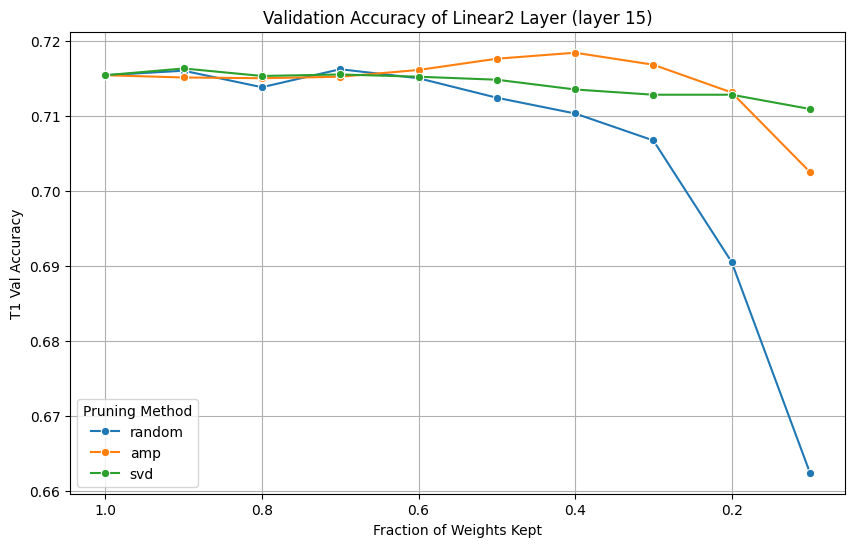

In [6]:
# only penultimate layer
i=-1
fig, ax = plt.subplots(figsize=(10, 6))
i = len(layer_names) - 1
layer_name = layer_names[i]
df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'val_accs', 'method'])
df['sparsity_level'] = sparsity_levels*3
df['val_accs'] = np.concatenate([val_accs_random_layerwise[i, :, 0], val_accs_amp_layerwise[i, :, 0], val_accs_svd_layerwise[i, :, 0]])
df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
p = sns.lineplot(data=df, x='sparsity_level', y='val_accs', hue='method', marker='o', ax=ax)
p.colors = colors
ax.set_title(f'Validation Accuracy of {layer_name} Layer (layer {i+1})')
ax.set_xlabel('Fraction of Weights Kept')
ax.set_ylabel('T1 Val Accuracy')
ax.legend(title='Pruning Method')
ax.grid()
ax.invert_xaxis()

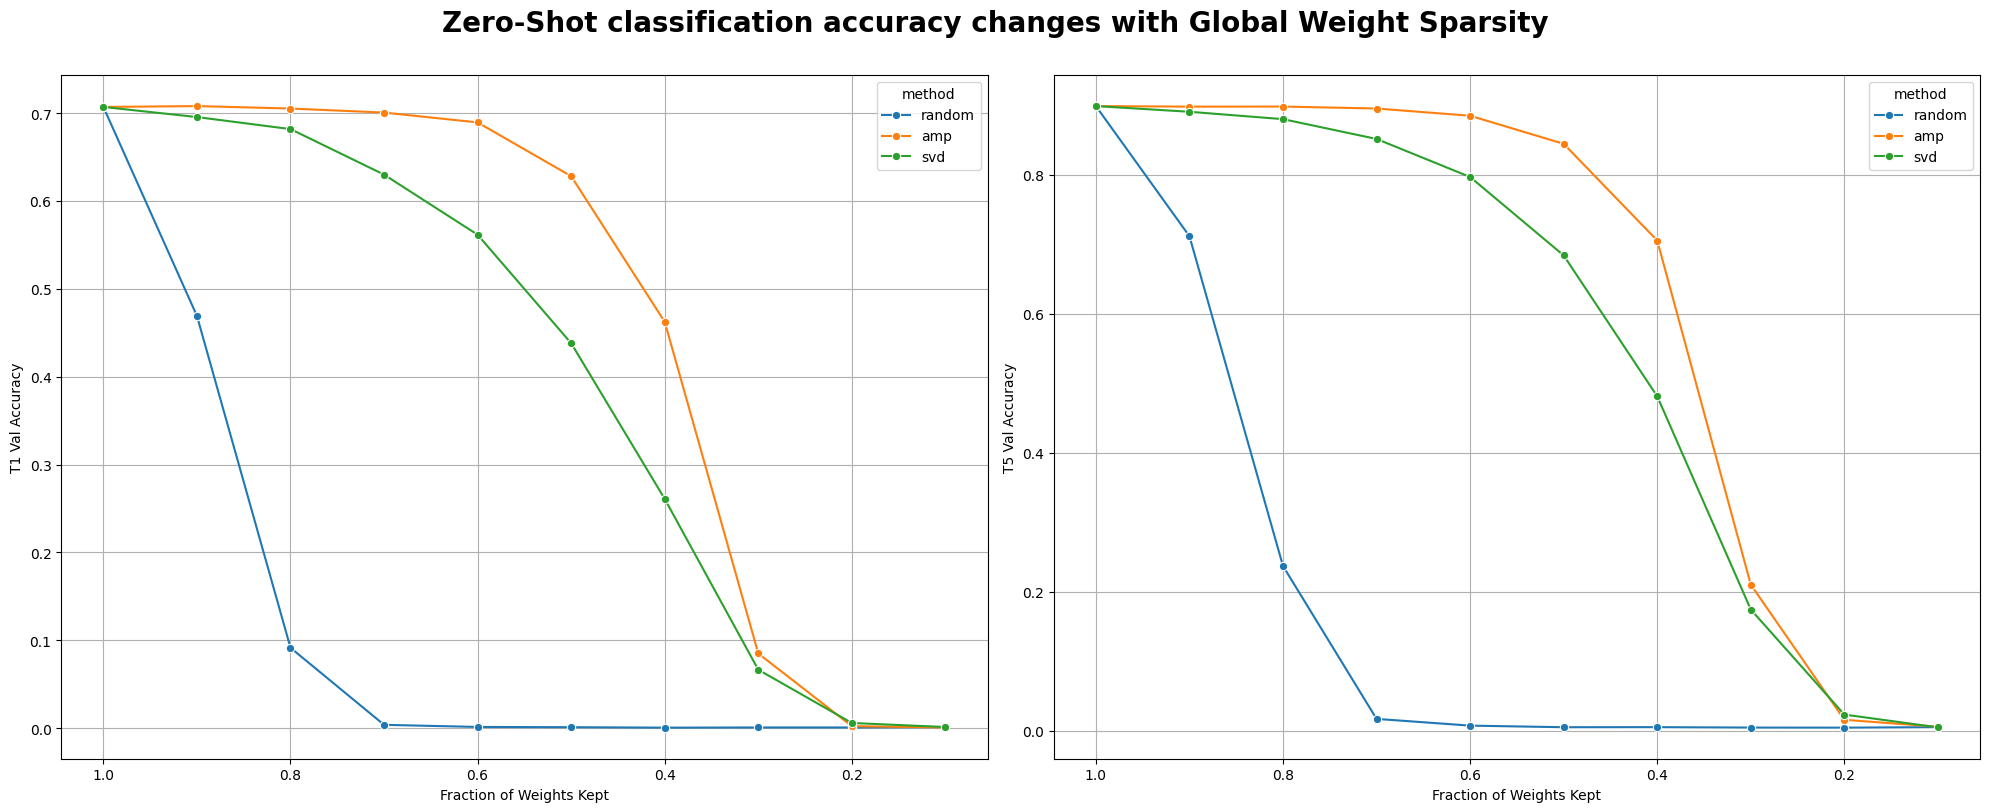

In [7]:
## Figure of validation accuracy changes with sparsity level for each method (all 3 methods) for all layers

val_accs_random_all = read_results(prune_method='random', metric='val_acc', prune_all=True) #[n_layers x n_sparsity_levels]
val_accs_amp_all = read_results(prune_method='amp', metric='val_acc', prune_all=True)
val_accs_svd_all = read_results(prune_method='svd', metric='val_acc', prune_all=True)


plot_df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'val_acc_1', 'val_acc_5', 'method'])
plot_df['sparsity_level'] = sparsity_levels*3
plot_df['val_acc_1'] = np.concatenate([val_accs_random_all[:, 0], val_accs_amp_all[:, 0], val_accs_svd_all[:, 0]])
plot_df['val_acc_5'] = np.concatenate([val_accs_random_all[:, 1], val_accs_amp_all[:, 1], val_accs_svd_all[:, 1]])
plot_df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  


# 2 subplots for top1 and top5 
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
sns.lineplot(data=plot_df, x='sparsity_level', y='val_acc_1', hue='method', marker='o', ax=axs[0])
axs[0].set_xlabel('Fraction of Weights Kept')
axs[0].set_ylabel('T1 Val Accuracy')
axs[0].grid()
axs[0].invert_xaxis()

sns.lineplot(data=plot_df, x='sparsity_level', y='val_acc_5', hue='method', marker='o', ax=axs[1])
axs[1].set_xlabel('Fraction of Weights Kept')
axs[1].set_ylabel('T5 Val Accuracy')
axs[1].grid()
axs[1].invert_xaxis()

fig.suptitle("Zero-Shot classification accuracy changes with Global Weight Sparsity", fontsize=20, y=1.01, fontweight="bold")
plt.tight_layout()

### Q1.  How does effective dimensionality change when whole model is pruned?

In [ ]:
##

### Q2. How does layerwise rep dim change when only that layer is pruned?

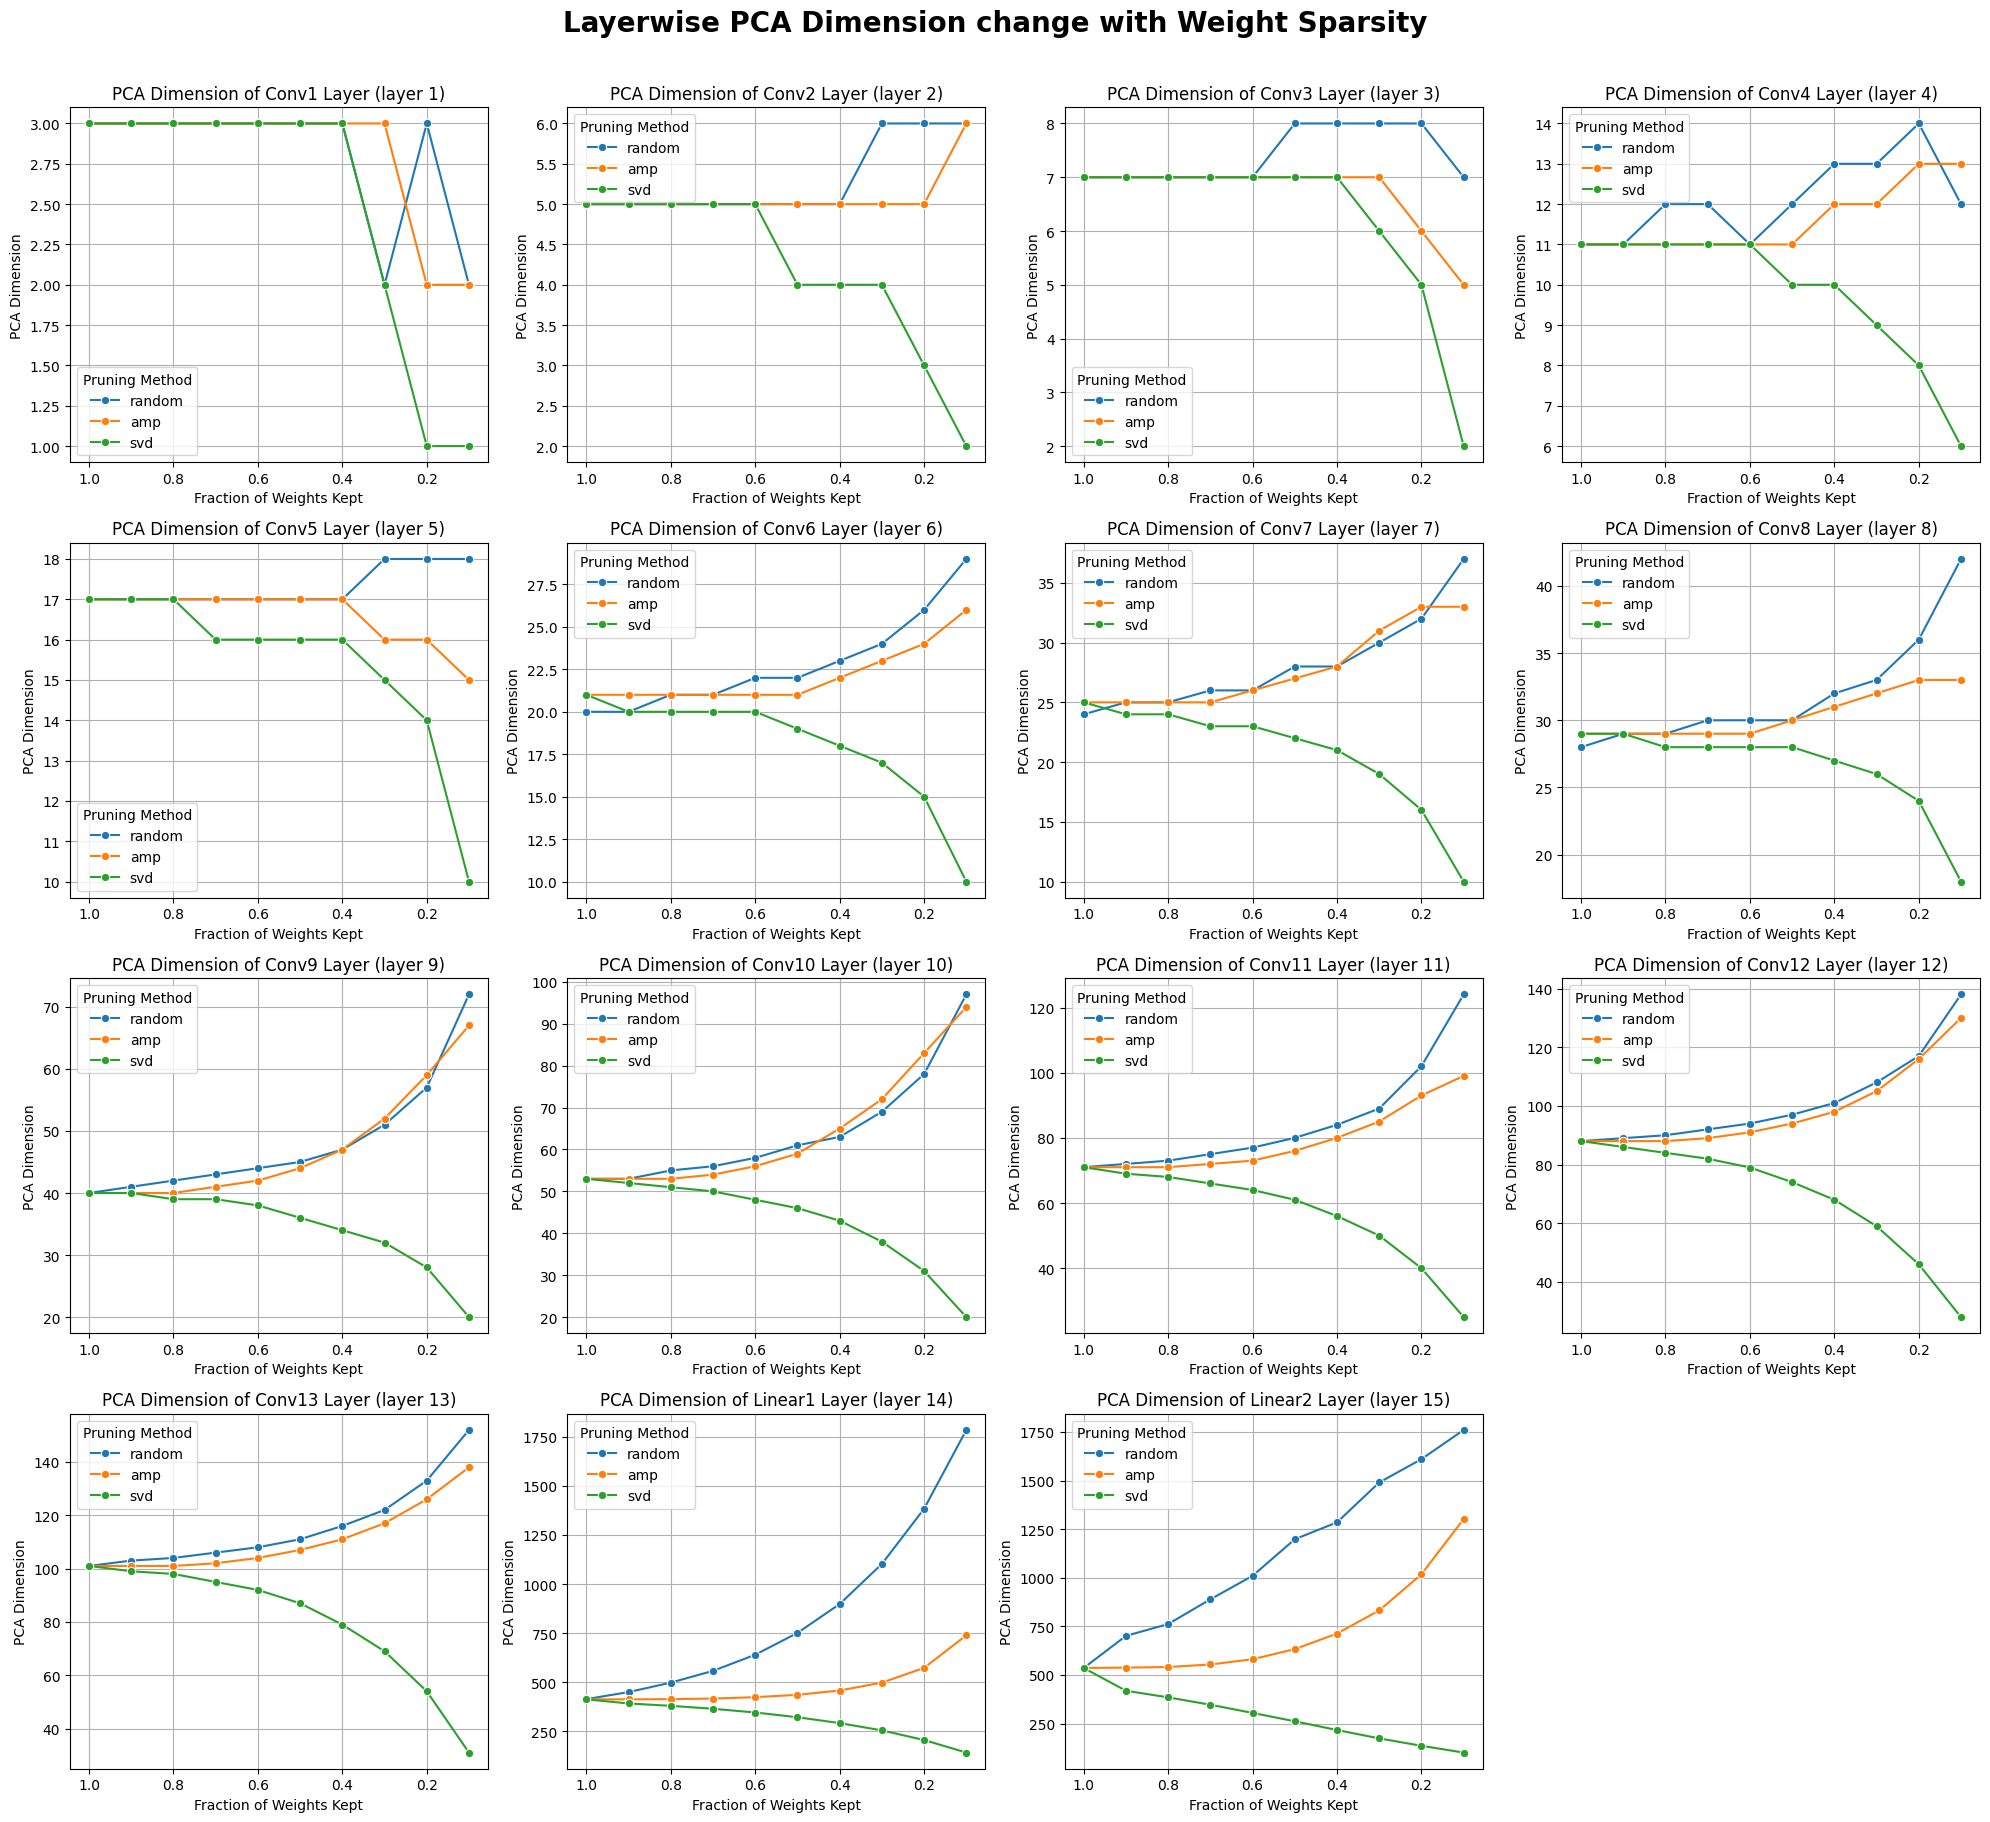

In [11]:
# subplots for each layer showing how the pca dim changes with sparsity level for each method (all 3 methods)
pca_dims_random_layerwise = read_results(prune_method='random', metric='pca_dim', prune_all=False) #[n_layers x n_sparsity_levels]
pca_dims_amp_layerwise = read_results(prune_method='amp', metric='pca_dim', prune_all=False)
pca_dims_svd_layerwise = read_results(prune_method='svd', metric='pca_dim', prune_all=False)

layer_names = get_layer_names(prune_method='random', metric='pca_dim', prune_all=False)
sparsity_levels = get_sparsity_levels(prune_method='random', metric='pca_dim', prune_all=False)

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 18))

for i, ax in enumerate(axs.flatten()):
    if i < len(layer_names):
        layer_name = layer_names[i]
        df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'pca_dim', 'method'])
        df['sparsity_level'] = sparsity_levels*3
        df['pca_dim'] = np.concatenate([pca_dims_random_layerwise[i, :], pca_dims_amp_layerwise[i, :], pca_dims_svd_layerwise[i, :]])
        df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
        sns.lineplot(data=df, x='sparsity_level', y='pca_dim', hue='method', marker='o', ax=ax)
        ax.set_title(f'PCA Dimension of {layer_name} Layer (layer {i+1})')
        ax.set_xlabel('Fraction of Weights Kept')
        ax.invert_xaxis()
        ax.set_ylabel('PCA Dimension')
        ax.legend(title='Pruning Method')
        ax.grid()
    else:
        ax.axis('off')

fig.suptitle("Layerwise PCA Dimension change with Weight Sparsity", fontsize=20, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

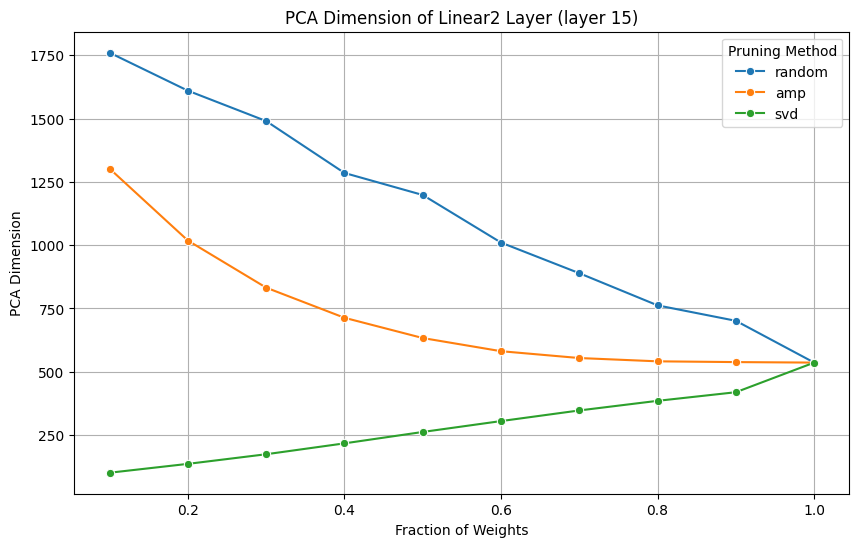

In [12]:
# plot just penultimate layer pca dim for all 3 methods
fig, ax = plt.subplots(figsize=(10, 6))
i = len(layer_names) - 1
layer_name = layer_names[i]
df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'pca_dim', 'method'])
df['sparsity_level'] = sparsity_levels*3
df['pca_dim'] = np.concatenate([pca_dims_random_layerwise[i, :], pca_dims_amp_layerwise[i, :], pca_dims_svd_layerwise[i, :]])
df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
sns.lineplot(data=df, x='sparsity_level', y='pca_dim', hue='method', marker='o', ax=ax)
ax.set_title(f'PCA Dimension of {layer_name} Layer (layer {i+1})')
ax.set_xlabel('Fraction of Weights')
ax.set_ylabel('PCA Dimension')
ax.legend(title='Pruning Method')
ax.grid()

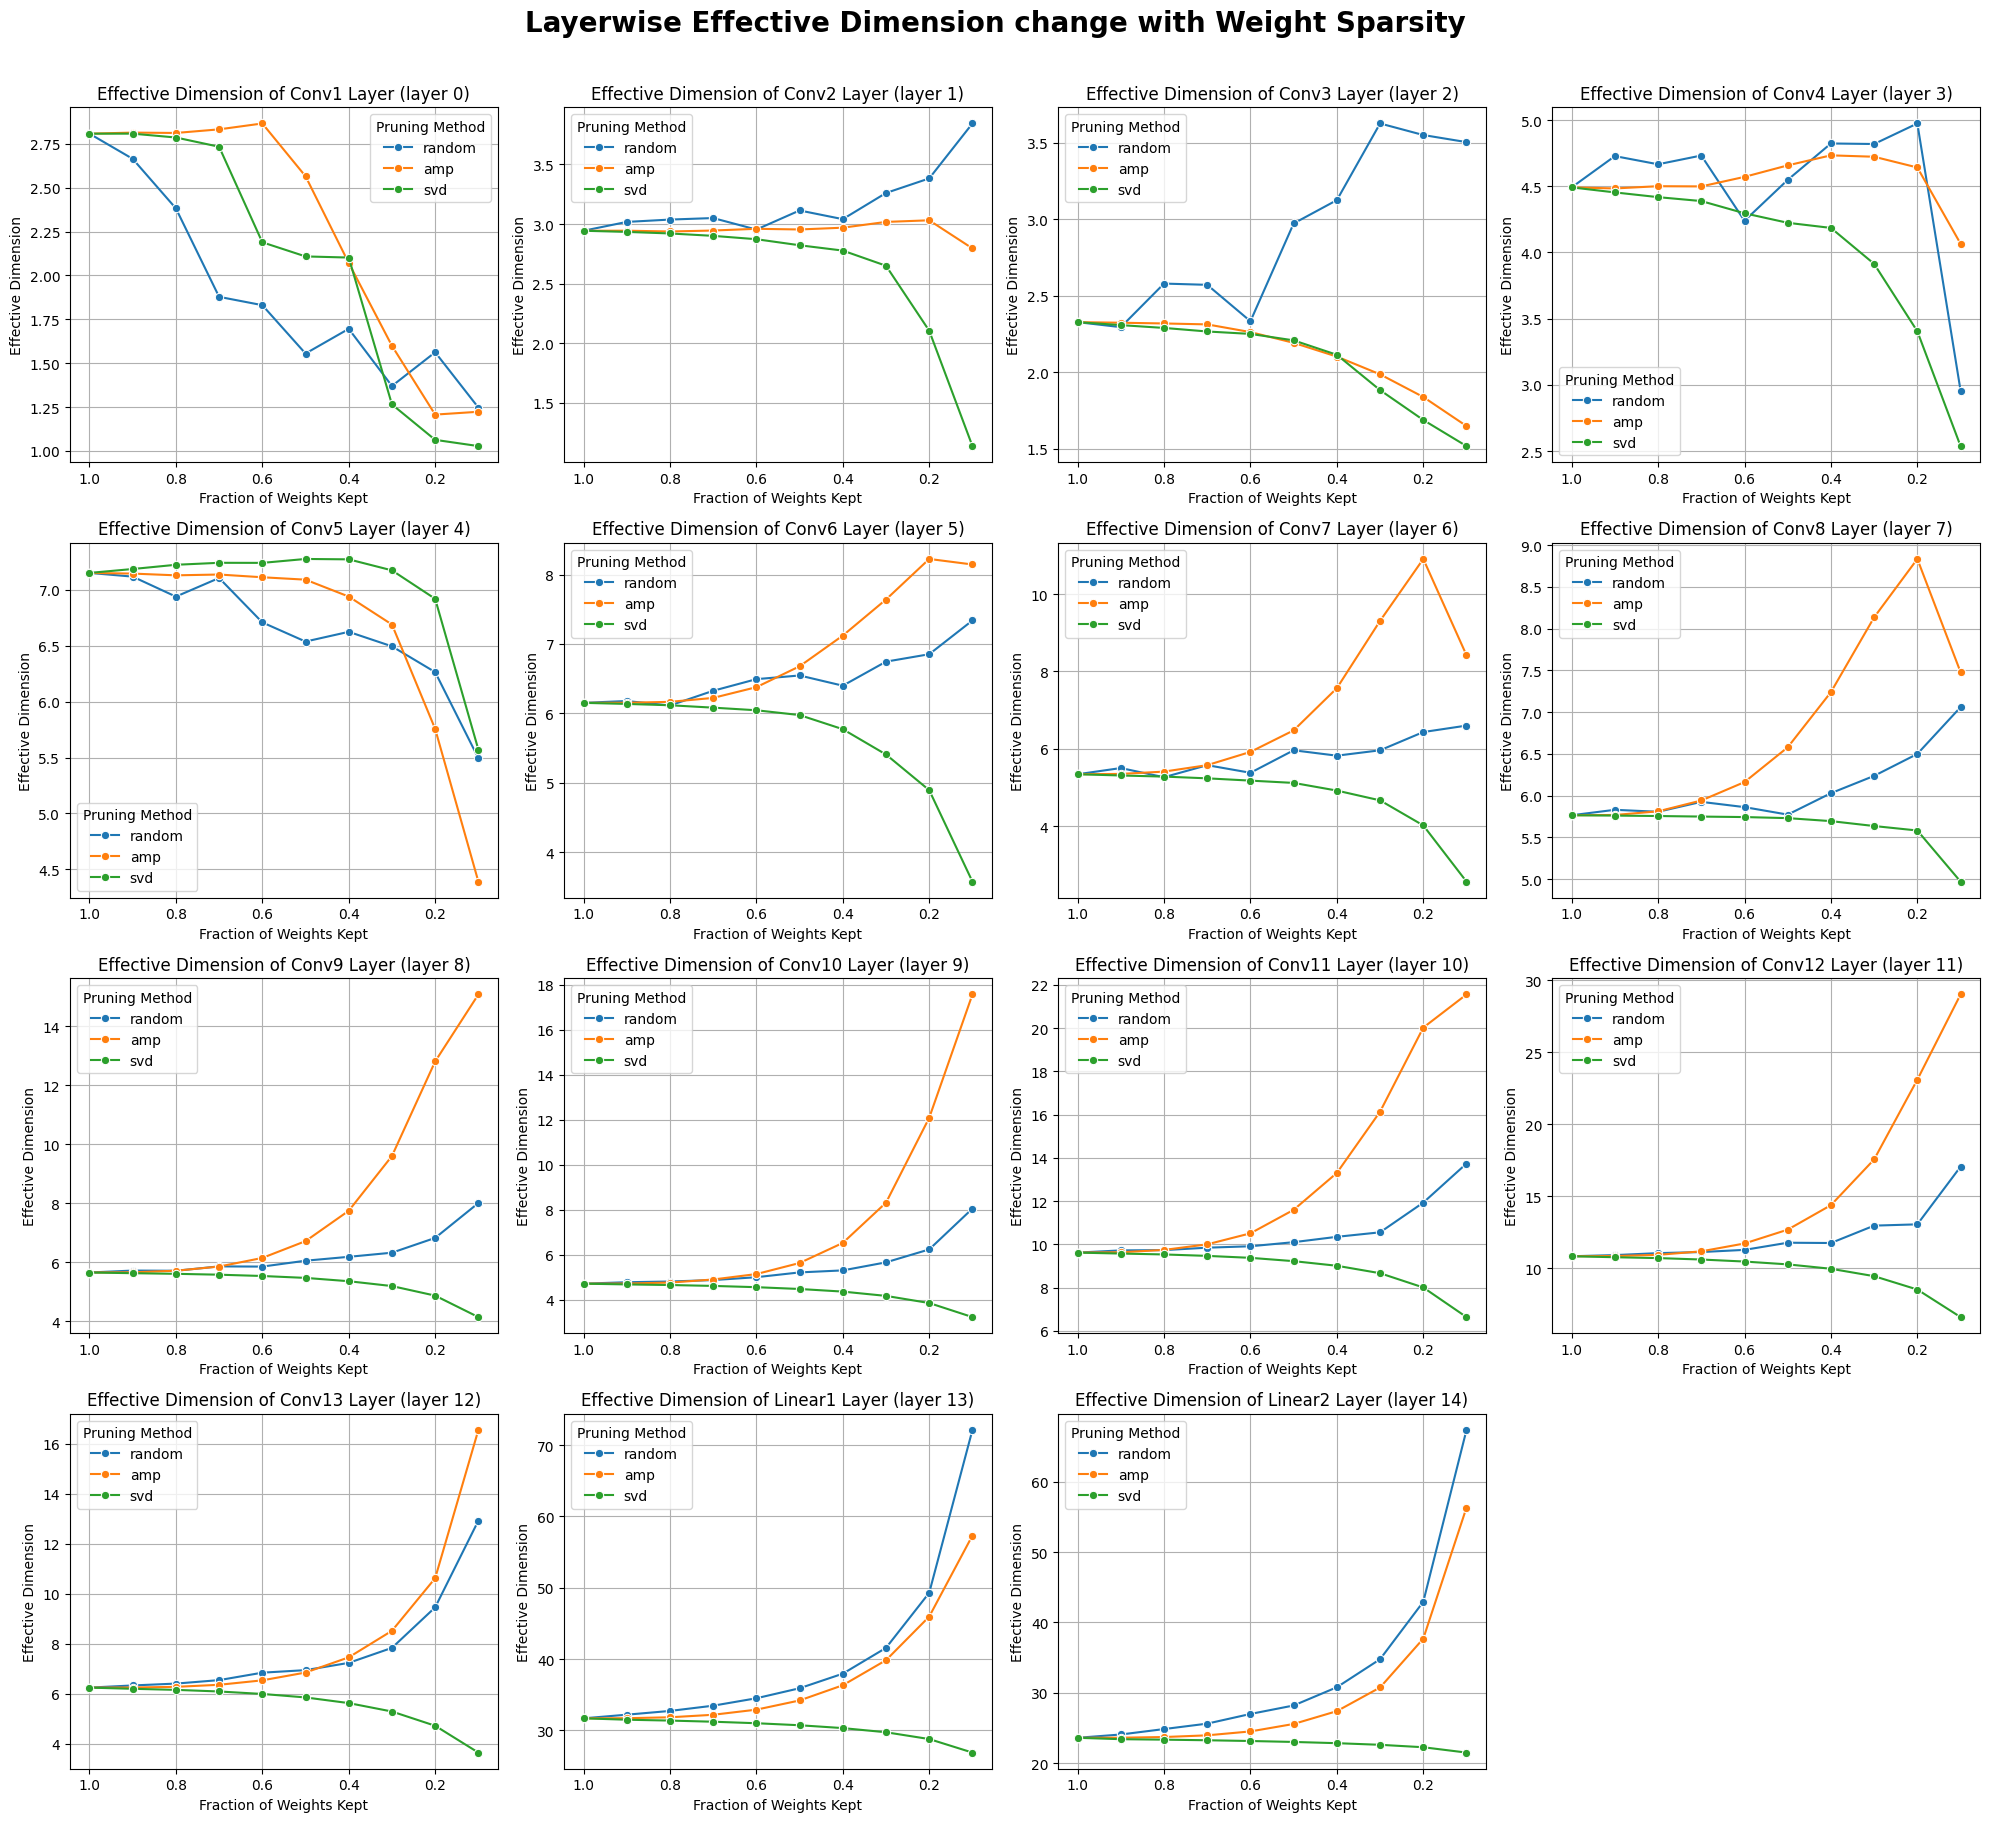

In [13]:
eff_dims_random_layerwise = read_results(prune_method='random', metric='eff_dim', prune_all=False) #[n_layers x n_sparsity_levels]
eff_dims_amp_layerwise = read_results(prune_method='amp', metric='eff_dim', prune_all=False)
eff_dims_svd_layerwise = read_results(prune_method='svd', metric='eff_dim', prune_all=False)


fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 18))

for i, ax in enumerate(axs.flatten()):
    if i < len(layer_names):
        layer_name = layer_names[i]
        df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'eff_dim', 'method'])
        df['sparsity_level'] = sparsity_levels*3
        df['eff_dim'] = np.concatenate([eff_dims_random_layerwise[i, :], eff_dims_amp_layerwise[i, :], eff_dims_svd_layerwise[i, :]])
        df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
        sns.lineplot(data=df, x='sparsity_level', y='eff_dim', hue='method', marker='o', ax=ax)
        ax.set_title(f'Effective Dimension of {layer_name} Layer (layer {i})')
        ax.set_xlabel('Fraction of Weights Kept')
        ax.invert_xaxis()
        ax.set_ylabel('Effective Dimension')
        ax.legend(title='Pruning Method')
        ax.grid()
    else:
        ax.axis('off')

fig.suptitle("Layerwise Effective Dimension change with Weight Sparsity", fontsize=20, y=1.01, fontweight="bold")
plt.tight_layout()

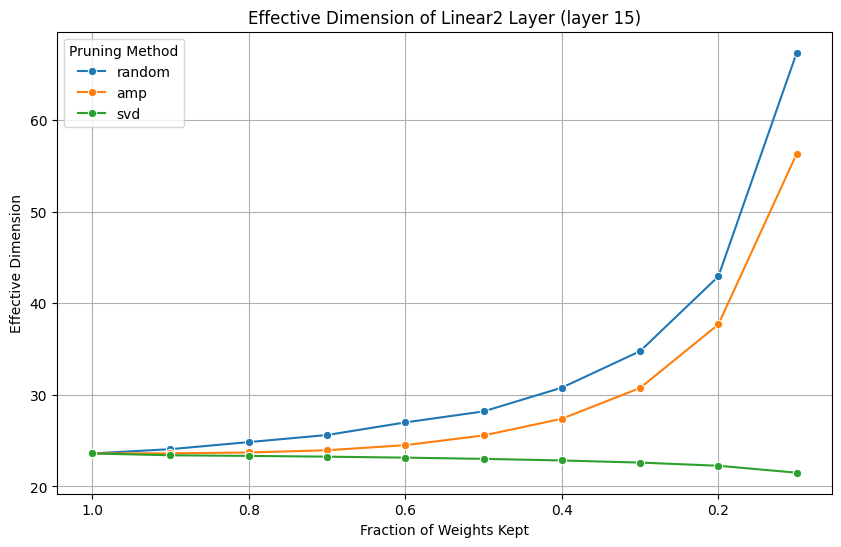

In [14]:
# plot just penultimate layer eff dim for all 3 methods
fig, ax = plt.subplots(figsize=(10, 6))
i = len(layer_names) - 1
layer_name = layer_names[i]
df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'eff_dim', 'method'])
df['sparsity_level'] = sparsity_levels*3
df['eff_dim'] = np.concatenate([eff_dims_random_layerwise[i, :], eff_dims_amp_layerwise[i, :], eff_dims_svd_layerwise[i, :]])
df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
sns.lineplot(data=df, x='sparsity_level', y='eff_dim', hue='method', marker='o', ax=ax)
ax.set_title(f'Effective Dimension of {layer_name} Layer (layer {i+1})')
ax.set_xlabel('Fraction of Weights Kept')
ax.set_ylabel('Effective Dimension')
ax.legend(title='Pruning Method')
ax.grid()
ax.invert_xaxis()

### Q3. Class Representation Geometry of Pruned Models

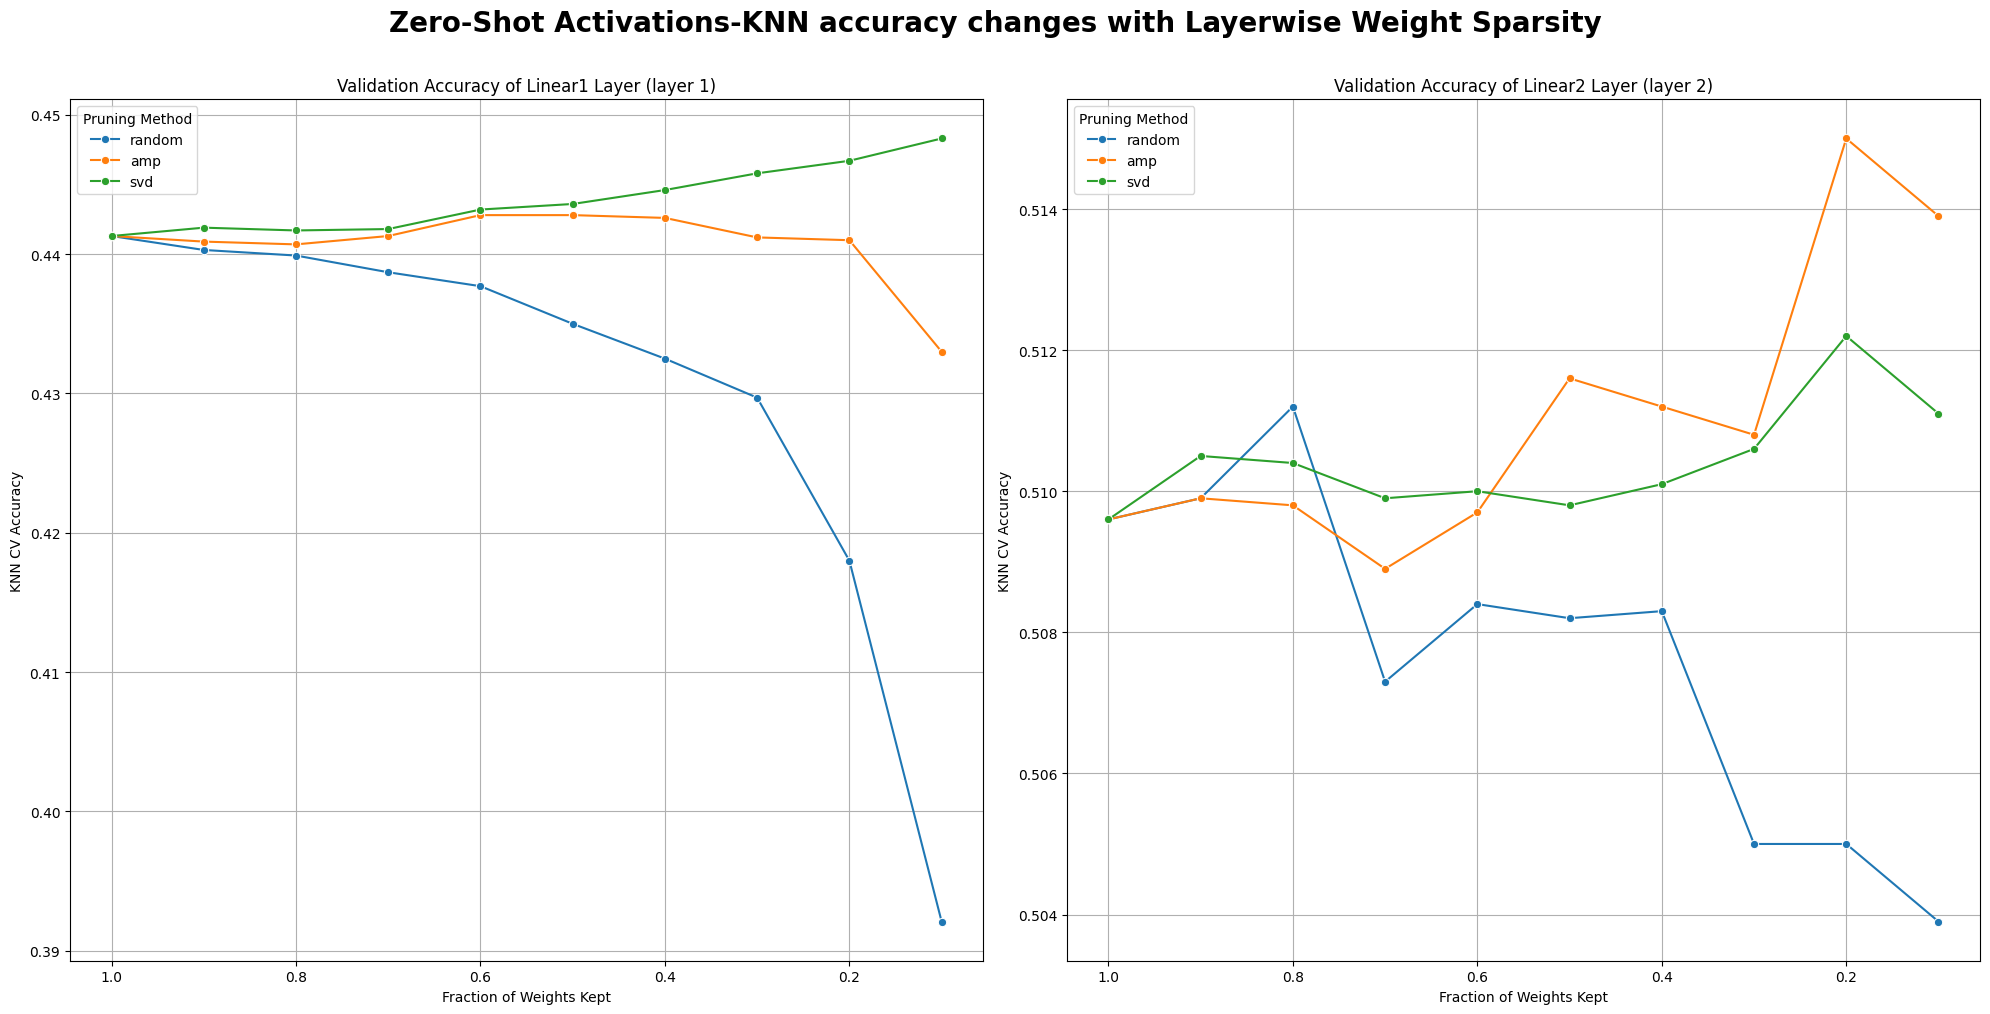

In [27]:
knn_accs_random_layerwise = read_results(prune_method='random', metric='knn_acc', prune_all=False) #[n_layers x n_sparsity_levels]
knn_accs_amp_layerwise = read_results(prune_method='amp', metric='knn_acc', prune_all=False)
knn_accs_svd_layerwise = read_results(prune_method='svd', metric='knn_acc', prune_all=False)

layer_names = get_layer_names(prune_method='random', metric='knn_acc', prune_all=False)
sparsity_levels = get_sparsity_levels(prune_method='random', metric='knn_acc', prune_all=False)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

for i, ax in enumerate(axs.flatten()):
    if i < len(layer_names):
        layer_name = layer_names[i]
        df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'knn_acc', 'method'])
        df['sparsity_level'] = sparsity_levels*3
        df['knn_acc'] = np.concatenate([knn_accs_random_layerwise[i, :], knn_accs_amp_layerwise[i, :], knn_accs_svd_layerwise[i, :]])
        df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
        sns.lineplot(data=df, x='sparsity_level', y='knn_acc', hue='method', marker='o', ax=ax)
        ax.set_title(f'Validation Accuracy of {layer_name} Layer (layer {i+1})')
        ax.set_xlabel('Fraction of Weights Kept')
        ax.set_ylabel('KNN CV Accuracy')
        ax.legend(title='Pruning Method')
        ax.grid()
        ax.invert_xaxis() 
    else:
        ax.axis('off')


fig.suptitle("Zero-Shot Activations-KNN accuracy changes with Layerwise Weight Sparsity", fontsize=20, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()